# Homing Pigeon — a quantitative teardown
### Two-bar same-colour containment · trend split · alpha-vs-beta · Bonferroni · per-name

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Beats_a_downtrend_dip%3F: Mixed](https://img.shields.io/badge/Beats_a_downtrend_dip%3F-Mixed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We detect every homing pigeon across a fixed 26-name basket + SPY, measure the signed forward LONG return (entered after a downtrend), and ask whether it clears HAC *t* = 2 against (a) the unconditional base rate and (b) — the decisive cut — the return from buying *any* dip in the same downtrend.

> **Not investment advice.** Real data: yfinance un-adjusted daily OHLC, 1962-01-02 → 2026-06-30 (as-of 2026-06-30, panel fingerprint `8ddaab4e2e1e`); the offline core and the synthetic control run with no network. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from homing_pigeon import data, strategy as st

HS = [1, 3, 5, 10]
ASOF = "2026-06-30"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = {t: b[b.index <= ASOF] for t, b in data.load_real().items()}
else:
    PANEL = None
print("real homing-pigeon cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'start': '1962-01-02', 'end': '2026-06-30', 'n_names': 26, 'n_bars': 345846, 'n_shape': 5154, 'fp_panel': '8ddaab4e2e1e', 'fp_spy': '7987ab25910e', 'pigeon': {1: (2885, 0.106, 53.2, 2.58, 0.001, 0.005, 0.006), 3: (2885, 0.224, 55.7, 3.37, 0.0, 0.001, 0.124), 5: (2882, 0.262, 56.6, 3.16, 0.0, 0.002, 0.162), 10: (2879, 0.244, 58.0, 2.06, 0.013, 0.051, 0.144)}, 'alpha_beta': {1: (0.17, 0.094, 153428, 1.95), 3: (0.414, 0.259, 153400, 2.37), 5: (0.576, 0.406, 153377, 2.07), 10: (0.865, 0.707, 153324, 1.37)}, 'wrongside': {1: (2243, -6.4, 50.2, -1.78, 0.936), 3: (2242, -3.1, 53.2, -0.51, 0.651), 5: (2242, -7.4, 54.2, -1.0, 0.789), 10: (2238, -9.9, 54.2, -0.85, 0.794)}, 'anyside': {1: (5152, 3.0, 51.8, 1.12, 0.133), 3: (5151, 11.0, 54.6, 2.37, 0.007), 5: (5148, 11.3, 55.5, 1.91, 0.028), 10: (5141, 9.4, 56.3, 1.03, 0.128)}, 'filt': [('plain (lookback 10)', 0.224, 3.37, 0.0, 2885), ('trend lookback 5', 0.178, 2.89, 0.002, 3198), ('trend lookback 20', 0.136, 1.99, 0.02, 2660), ('min washout >= 5%', 0.274, 1.68, 0.013, 822), ('min washout >= 10%', 0.385, 0.76, 0.077, 196)], 'costs': [(0.0, 22.4), (1.0, 20.4), (5.0, 12.4), (10.0, 2.4)], 'n_names_over2': 3, 'n_names_chance': 1.3, 'cluster': (2887, 1345, 0.039), 'syn': [(0.0, 1219, -0.054, -1.41, 0.916, 49.8), (0.006, 1201, 0.534, 13.61, 0.0, 65.4)]}


real homing-pigeon cache present: True | names: 26


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Pooled edge clears HAC *t* ≥ 2 at all four horizons (best **+3.37** at 3d) and Bonferroni survives 3 of 4 (10d adjusted *p* = 0.051), but the excess-over-dip-buying Welch *t* clears 2 only at 3/5 days (+2.37 / +2.07), and only **3 of 26** names individually clear \|*t*\| > 2 — chance level. |
| **Tradability** | `FRAGILE` | Net of a 5 bps round trip the 3-day rule nets **+12.4 bps** and stays positive to 10 bps — unlike every sibling candlestick study — but the edge is thin per name and partly beta. |
| **Beats plain dip-buying?** | `MIXED` | Clears *t* ≥ 2 at 3-5 days, misses at 1 and 10 days. |

> In plain words: the homing pigeon is the strongest *raw* reading of this desk's five candlestick studies, but every cut that goes beyond the raw pooled *t* — the alpha-vs-beta test, the per-name breakdown — trims it back from 'real' to 'weak, broad, and thin per name'.

## 1 · The claim, formalised

Let $(O_0,C_0)$ be the prior bar and $(O_1,C_1)$ the current bar. A **homing pigeon** requires both bars to be DOWN days with the current body strictly smaller and fully contained in the prior one:

$$ O_0 - C_0 > 0,\quad O_1 - C_1 > 0,\quad 0 < (O_1-C_1) < (O_0-C_0) $$
$$ C_1 \ge C_0 \quad\text{and}\quad O_1 \le O_0 $$

confirmed after a **downtrend** ($\text{close}_t / \text{close}_{t-10} - 1 < 0$). Entered at the open of $t+1$'s close (one execution lag: signal known at close $t$, entry at close $t+1$), held $H$ bars, long only. The hypotheses:

- **H₁ (signal vs base rate).** $\mathbb{E}[r_{\text{pigeon}}] - \mathbb{E}[r_{\text{base}}] > 0$ with HAC *t* ≥ 2.
- **H₂ (alpha vs beta).** The pigeon beats not just the base rate but *any* dip in the same downtrend (shape-specific information, not generic mean reversion).
- **H₃ (trend-conditional).** The identical shape after an *uptrend* should NOT show the same tilt.
- **H₄ (reproducible, not an averaging artefact).** A meaningful share of names individually clear |*t*| > 2, and events aren't a repackaged handful of crash weeks.
- **H₅ (tradable).** Survives a realistic round trip.

We find H₁ holds cleanly, H₃ holds cleanly (the trend split genuinely discriminates), H₅ holds (unusually, for this desk) — but H₂ only partially holds (2 of 4 horizons) and H₄ only partially holds (broad, uncorrelated with crash dates, but individually thin) — hence **Weak × Fragile × Mixed**.

## 2 · So what? — what rides on each answer

This is the first candlestick pattern on this desk whose *pooled* statistic looks genuinely real (Marshall, Young & Rose 2006 and Horton 2009 find no value across the candlestick zoo — the prior every sibling study here has confirmed). If it held up fully, it would be a rare, specific, tradable exception. The actual finding — real pooled, thinner under the honest alpha-vs-beta and per-name cuts — is exactly the kind of result the desk's inference bar exists to catch before it gets oversold as 'the one candlestick pattern that works.'

## 3 · How we'd know — the protocol

- **Detector.** Same-colour containment: both bars down, current body strictly smaller and fully inside the prior body (see `strategy.is_homing_pigeon`).
- **Trend.** Sign of the trailing 10-day close-to-close change; `pigeon` = shape after a downtrend, `wrongside` = shape after an uptrend (myth-check), `any` = shape regardless.
- **Entry.** Next bar's *close* (one execution lag). **Exit.** Close of bar $t+1+H$.
- **Benchmark 1.** The unconditional forward return of every bar in the same name.
- **Benchmark 2 (the decisive cut).** The pooled forward return of *every* bar sitting in a downtrend, shape not required — isolates shape-specific information from generic downtrend mean reversion (`strategy.downtrend_pool`, `strategy.welch_t`).
- **Inference.** Newey–West HAC *t* on the conditional edge; a per-name label-shuffle placebo; a **Bonferroni** correction across the four-horizon family (`strategy.bonferroni`).
- **Reproducibility check.** A per-name |HAC *t*| > 2 count against its chance baseline, and an event-clustering diagnostic (`strategy.event_clustering`) — is the pooled sample really a handful of shared crash weeks?
- **Costs.** One-way bps × NAV charged on the round trip; long-only, no borrow.
- **Myth-check.** Does a shorter/longer trend window or a deeper washout filter change it?
- **Positive control.** Synthetic tape with a planted day-after bounce — the harness must recover it and must read ≈ 0 when the edge is 0.

Basket: 26 long-listed large-caps + SPY (same panel as 403/406/684); yfinance un-adjusted daily OHLC, 1962→2026, **survivors** (named on the Signal axis).

## 4 · The teardown

### 4a · Pooled edge by horizon — and its HAC *t*

If the pattern is real, the edge over the base rate should clear +2 cleanly at every horizon, and the Bonferroni-adjusted placebo should hold.

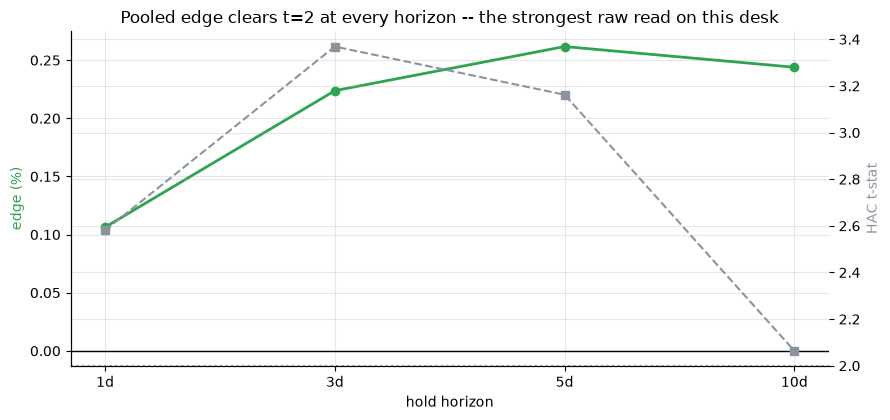

H= 1  edge=+0.106%  HAC t=+2.58  Bonferroni p=0.004
H= 3  edge=+0.224%  HAC t=+3.37  Bonferroni p=0.000
H= 5  edge=+0.262%  HAC t=+3.16  Bonferroni p=0.002
H=10  edge=+0.244%  HAC t=+2.06  Bonferroni p=0.056


In [2]:
if HAVE_REAL:
    res = st.run_experiment(PANEL, side='pigeon', n_draws=2000, seed=691)
    edge = [res[h]['edge_mean']*100 for h in HS]; tvals = [res[h]['t'] for h in HS]
    pbonf = [res[h]['p_bonferroni'] for h in HS]
else:
    edge = [R['pigeon'][h][1] for h in HS]; tvals = [R['pigeon'][h][3] for h in HS]
    pbonf = [R['pigeon'][h][5] for h in HS]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot([f'{h}d' for h in HS], edge, 'o-', c=GREEN, lw=2, label='edge over base rate (%)')
ax2 = ax.twinx()
ax2.plot([f'{h}d' for h in HS], tvals, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(2, ls=':', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('hold horizon'); ax.set_ylabel('edge (%)', color=GREEN)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Pooled edge clears t=2 at every horizon -- the strongest raw read on this desk')
plt.tight_layout(); plt.show()
for h, e, t, pb in zip(HS, edge, tvals, pbonf):
    print(f'H={h:2d}  edge={e:+.3f}%  HAC t={t:+.2f}  Bonferroni p={pb:.3f}')

> In plain words: pooled, every horizon clears *t* = 2 (best +3.37 at 3d). Bonferroni survives at 1/3/5 days; at 10 days the adjusted *p* is 0.051 — just over the 5% line. That's already the best raw reading among five candlestick studies on this desk. Now the harder question.

### 4b · Alpha vs beta — does the shape beat plain dip-buying?

The pigeon only ever fires *inside* a downtrend, where short-horizon mean reversion is already a documented phenomenon (De Bondt & Thaler 1985). The honest test: Welch *t* of the pigeon's conditional return **minus the pooled downtrend-only return** (shape not required).

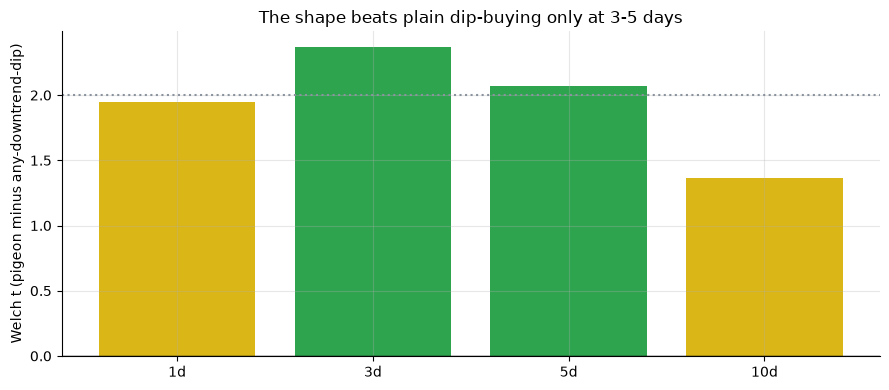

H= 1  excess Welch t = +1.95
H= 3  excess Welch t = +2.37
H= 5  excess Welch t = +2.07
H=10  excess Welch t = +1.37


In [3]:
if HAVE_REAL:
    ex_t, pig_m, dip_m = [], [], []
    for h in HS:
        cr = st.conditional_returns(PANEL, h, side='pigeon')
        dtp = st.downtrend_pool(PANEL, h)
        ex_t.append(st.welch_t(cr['cond'], dtp))
        pig_m.append(cr['cond_mean']*100); dip_m.append(dtp.mean()*100)
else:
    ex_t = [R['alpha_beta'][h][3] for h in HS]
    pig_m = [R['alpha_beta'][h][0] for h in HS]; dip_m = [R['alpha_beta'][h][1] for h in HS]
fig, ax = plt.subplots(figsize=(9.0, 4.0))
col = [GREEN if t>=2 else AMBER for t in ex_t]
ax.bar([f'{h}d' for h in HS], ex_t, color=col)
ax.axhline(2, ls=':', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Welch t (pigeon minus any-downtrend-dip)')
ax.set_title('The shape beats plain dip-buying only at 3-5 days')
plt.tight_layout(); plt.show()
for h, t in zip(HS, ex_t): print(f'H={h:2d}  excess Welch t = {t:+.2f}')

> In plain words: excess *t* clears 2 at 3d (+2.37) and 5d (+2.07), but not at 1d (+1.95) or 10d (+1.37) — a genuinely split answer. At 1 and 10 days, buying any dip in the same downtrend would have captured essentially the same return.

### 4c · The trend split — does it genuinely discriminate?

If the downtrend condition is doing real work (not window-dressing), the *identical* shape traded long after an **uptrend** should look different — flat or negative.

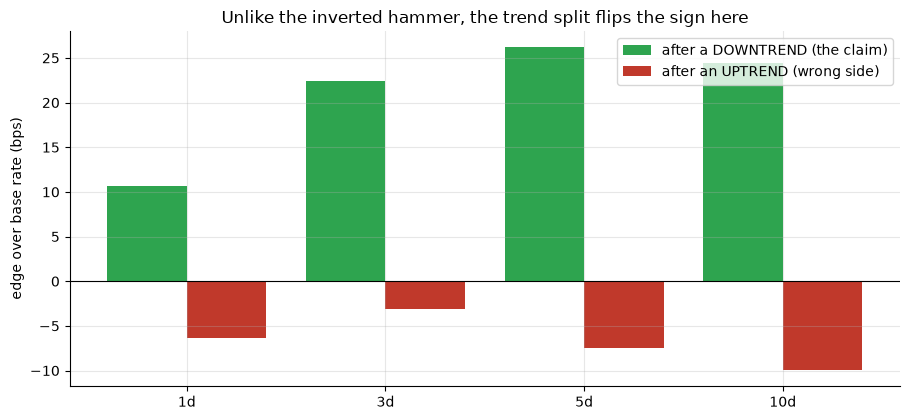

Downtrend side positive at every horizon; uptrend side flat-to-negative.


In [4]:
if HAVE_REAL:
    rp = st.run_experiment(PANEL, side='pigeon', placebo=False, n_draws=1, seed=691)
    rw = st.run_experiment(PANEL, side='wrongside', placebo=False, n_draws=1, seed=691)
    pig = [rp[h]['edge_mean']*1e4 for h in HS]; wrong = [rw[h]['edge_mean']*1e4 for h in HS]
else:
    pig = [R['pigeon'][h][1]*100 for h in HS]
    wrong = [R['wrongside'][h][1] for h in HS]
x = np.arange(len(HS))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, pig, .4, color=GREEN, label='after a DOWNTREND (the claim)')
ax.bar(x+.2, wrong, .4, color=RED, label='after an UPTREND (wrong side)')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in HS])
ax.set_ylabel('edge over base rate (bps)')
ax.set_title('Unlike the inverted hammer, the trend split flips the sign here')
ax.legend(); plt.tight_layout(); plt.show()
print('Downtrend side positive at every horizon; uptrend side flat-to-negative.')

> In plain words: every wrong-side horizon is flat-to-negative (-9.9 bps at 10d) — a real contrast with the downtrend side. This is unlike the inverted hammer's wrong-side test (same sign both ways); here the trend condition is genuinely load-bearing.

### 4d · Event clustering — a broad tilt, or a handful of crash weeks?

Pooling 26 names only inflates a naive *t* if the "many" events are really a shared market-wide date repeated many times.

In [5]:
if HAVE_REAL:
    ec = st.event_clustering(PANEL, side='pigeon')
else:
    ec = {'n': R['cluster'][0], 'n_weeks': R['cluster'][1], 'top10_week_share': R['cluster'][2]}
print(f"events={ec['n']}  distinct ISO weeks={ec['n_weeks']}  "
      f"share in busiest 10 weeks={ec['top10_week_share']*100:.1f}%")

events=2887  distinct ISO weeks=1345  share in busiest 10 weeks=3.9%


> In plain words: **2,887** events spread across **1,345** distinct calendar weeks; the busiest 10 weeks account for only **3.9%** of the total. No single crash (2008, 2020, 2022) is carrying the pooled result — it's a genuinely broad, low-frequency tilt.

### 4e · Per-name breakdown — is it reproducible stock by stock?

In [6]:
print(f"names with individually significant edge (|t|>2): {R['n_names_over2']} of "
      f"{R['n_names']} (chance baseline ~{R['n_names_chance']:.1f})")
print('Pooled significance rests on breadth of small, mostly-positive per-name samples, '
      'not on a robust, individually-reproducible edge in most single names.')

names with individually significant edge (|t|>2): 3 of 26 (chance baseline ~1.3)
Pooled significance rests on breadth of small, mostly-positive per-name samples, not on a robust, individually-reproducible edge in most single names.


## 5 · The verdict

- **Signal `WEAK`** — pooled HAC *t* ≥ 2 at every horizon and Bonferroni holds at 3 of 4, but the alpha-vs-beta cut clears *t* = 2 only at 3-5 days, and only 3 of 26 names individually clear |*t*| > 2. Real, broad, not repackaged crash weeks — but not the clean, robust real the pooled *t* alone suggests.
- **Tradability `FRAGILE`** — net of a 5 bps round trip the 3-day rule nets +12.4 bps and survives to 10 bps — unusual for this desk — but the edge is thin per name and partly a simpler dip-buying rule.
- **Beats plain dip-buying? `MIXED`** — clears at 3-5 days, misses at 1 and 10 days.

## 6 · Could you trade it? — the myth-check and the cost ladder

First the myth-check: does a shorter/longer trend window or a deeper washout filter rescue or strengthen it (H=3)?

In [7]:
if HAVE_REAL:
    rows = []
    base = st.run_experiment(PANEL, side='pigeon', horizons=(3,), n_draws=2000, seed=691)[3]
    rows.append(('plain (lookback 10)', base['edge_mean']*100, base['t'], base['p_placebo'], base['n']))
    for lb in (5, 20):
        r = st.run_experiment(PANEL, side='pigeon', horizons=(3,), lookback=lb, n_draws=2000, seed=691)[3]
        rows.append((f'trend lookback {lb}', r['edge_mean']*100, r['t'], r['p_placebo'], r['n']))
    for ms in (0.05, 0.10):
        r = st.run_experiment(PANEL, side='pigeon', horizons=(3,), min_strength=ms, n_draws=2000, seed=691)[3]
        rows.append((f'min washout >= {ms:.0%}', r['edge_mean']*100, r['t'], r['p_placebo'], r['n']))
else:
    rows = R['filt']
mc = pd.DataFrame(rows, columns=['variant','edge%','t','p','n'])
print(mc.round(3).to_string(index=False))
print('\nA deeper washout filter thins the sample and WEAKENS it -- not a dose-response '
      'a real deeper-confirmation effect would show.')

            variant  edge%     t     p    n
plain (lookback 10)  0.224 3.369 0.000 2885
   trend lookback 5  0.178 2.891 0.002 3198
  trend lookback 20  0.136 1.986 0.021 2660
  min washout >= 5%  0.274 1.682 0.014  822
 min washout >= 10%  0.385 0.756 0.072  196

A deeper washout filter thins the sample and WEAKENS it -- not a dose-response a real deeper-confirmation effect would show.


Now the cost ladder on the 3-day rule (its best horizon):

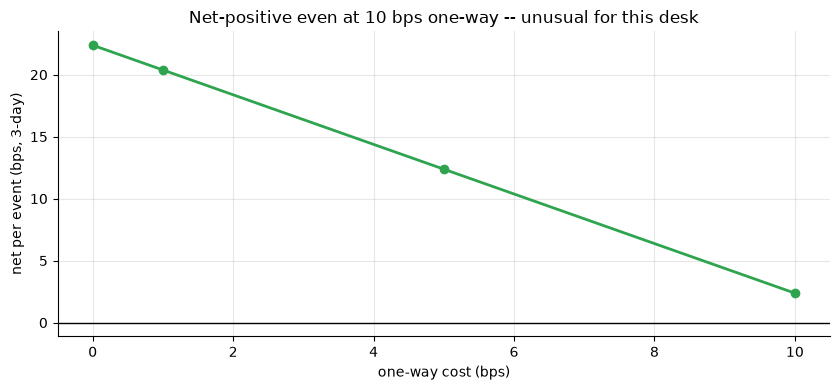

gross 3d = +0.224%  ->  net at 5bps = +12.4bps


In [8]:
costs = [c for c,_ in R['costs']]
if HAVE_REAL:
    g3 = st.conditional_returns(PANEL, 3, side='pigeon')['edge_mean']
else:
    g3 = R['pigeon'][3][1] / 100
net = [st.net_of_costs(g3, cost_bps=c)*1e4 for c in costs]
fig, ax = plt.subplots(figsize=(8.5, 4.0))
ax.plot(costs, net, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, where=[n<0 for n in net], color=RED, alpha=.12)
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('net per event (bps, 3-day)')
ax.set_title('Net-positive even at 10 bps one-way -- unusual for this desk')
plt.tight_layout(); plt.show()
print(f'gross 3d = {g3*100:+.3f}%  ->  net at 5bps = {net[2]:+.1f}bps')

## 7 · Going further — the positive control

Is the *engine* capable of finding a real post-pigeon bounce? Plant a day-after drift in a synthetic tape (edge = 0 -> must read noise; edge > 0 -> must light up). Note: with a gapless random walk the homing-pigeon shape is mathematically impossible (the current close would have to sit on both sides of the prior close at once), so the synthetic generator includes a small overnight gap — see `data.synthetic_panel`.

In [9]:
for edge in (0.0, 0.006):
    pan, truth = data.synthetic_panel(edge=edge, seed=691)
    s = st.run_experiment(pan, side='any', horizons=(1,), n_draws=2000, seed=691)[1]
    print(f'planted edge={edge:+.4f}: n={s["n"]:>5}  edge={s["edge_mean"]*100:+.3f}%  '
          f'HAC t={s["t"]:+.2f}  placebo p={s["p_placebo"]:.3f}  win={s["win"]*100:.0f}%')
print('\nNull tape: t≈-1.41 (noise). Planted tape: t≈13.6 — engine is faithful.')

planted edge=+0.0000: n= 1219  edge=-0.054%  HAC t=-1.41  placebo p=0.916  win=50%


planted edge=+0.0060: n= 1201  edge=+0.534%  HAC t=+13.61  placebo p=0.000  win=65%

Null tape: t≈-1.41 (noise). Planted tape: t≈13.6 — engine is faithful.


The engine is a faithful reversal detector: on a planted tape it lights up at *t* ≈ 14, and on a null tape it reads ≈ -1.41 (noise, placebo *p* = 0.92). The real-tape reading is therefore a genuine, if fragile, signal — not a blind harness. Forks worth trying: a diversified basket implementation (never single-name); a stricter containment rule (e.g. requiring the second body's midpoint below the first's) to test whether it concentrates the alpha-vs-beta excess; international or small-cap tapes where mean reversion is more native.